# Setup

In [1]:
# make sure you're in the categories env when you run this notebook

import glob, os, ast, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bambi import Model
import scipy.stats as stats
import random
%run 'Tools/preprocess_mturk_data.py'
warnings.filterwarnings(action='once')

# set plotting style 
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.set_context("poster")
sns.set(style="ticks",font="Arial",font_scale=2)

# pd settings
pd.set_option('display.max_columns', None)

# Preprocess data and clean outliers
We use a function to preprocess the data (loading individual data, concatenating them, and seperating into the different experimental phases), and then load the summary csvs. 
We start by loading data from all participants, then we check for outliers and remove them. 

### preprocess data

In [2]:
# if we need to preprocess the data, run this line
process_mturk_csv('../../../../Art_experiment/Java_experiment/Version10/Data', 'condition', 'V1')

INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [3]:
# load csvs
# Dan's version
keys = ["ratings", "deliberation", "interference", "reward_learning", \
        "final_decisions", "memory", "all_data", "all_interaction_data", "debrief"]
path_to_data = "../Data/Summary_data/all_subs"
dfs_all_subs = {} # create a dictionary

for i, key in enumerate(keys):
    dfs_all_subs[key] = pd.read_csv(os.path.join(path_to_data, key + ".csv"))
    if "Unnamed: 0" in dfs_all_subs[key].columns:
        dfs_all_subs[key] = dfs_all_subs[key].drop(columns = "Unnamed: 0")


Check how many non-responses participants had

In [4]:
# non responses 
no_responses_final_decisions = dfs_all_subs["final_decisions"].groupby("PID").agg(
    total = ("rt",lambda x: len(x)),
    n_nan = ("rt", lambda x: pd.isnull(x).sum()),
    percent = ("rt",lambda x: pd.isnull(x).sum()/len(x)*100))
#no_responses_final_decisions

Test how long the experiment usually takes

In [5]:
# duration
subs = np.unique(dfs_all_subs["all_data"].PID)
duration = pd.DataFrame(columns=["PID", "minutes"])
for i in range(len(subs)):
    x = dfs_all_subs["all_data"].loc[dfs_all_subs["all_data"].PID == subs[i]]
    duration.loc[i,"PID"] = subs[i];
    duration.loc[i,"minutes"] = (x.loc[x.category == "debreif_end","time_elapsed"].iloc[0] - x.loc[x.category == "full_screen","time_elapsed"].iloc[0])/60000;

#duration

### Compute bonus money 

In [6]:
# compute bonus money 
bonus_money = dfs_all_subs["all_data"].loc[dfs_all_subs["all_data"].category == "debreif_clear_instructions",["PID","total_reward_tally"]].reset_index().drop(columns="index")
fd_bonus = 2; n_FD_trials = 144; deliberation_reward_tally = 1.5
bonus_per_trial = fd_bonus/(n_FD_trials/2); 
for index, row in bonus_money.iterrows():
    bonus_money.loc[index, "computed_bonus"] = round(sum(dfs_all_subs["final_decisions"].loc[(dfs_all_subs["final_decisions"]["PID"] == bonus_money.loc[index, "PID"]) & (dfs_all_subs["final_decisions"]["rt"].notna() & (dfs_all_subs["final_decisions"]["chosen_trial"]==1)),"higher_outcome_chosen"]) * bonus_per_trial + deliberation_reward_tally, 2)

# load subjects log to compute bonus money
if os.path.exists('../../../../Art_experiment/Java_experiment/Version10/Data/subs_log/subs_log.csv'):
    worker_id = pd.read_csv("../../../../Art_experiment/Java_experiment/Version10/Data/subs_log/subs_log.csv").rename(columns = {"Actual Completion Code": "PID"})
    worker_id = worker_id.loc[worker_id.ApprovalStatus == "Pending",]
    worker_id = worker_id[["AmazonIdentifier", "PID"]]
    bonus = worker_id.merge(bonus_money, on="PID", how="left")
    bonus = bonus[["AmazonIdentifier", "total_reward_tally"]]
    bonus.rename_axis(None)
    bonus.to_csv("../../../../Art_experiment/Java_experiment/Version10/Data/Bonus/bonus.csv", header=False, index=False)

### Find outliers

check outlier subjects using the warnings collected in the experiment and the interaction data

In [7]:
# outlier criteria
blur_focus_criterion = 25;
missed_instructions_criterion = 10; 
final_decisions_non_responses_criterion = 25; 
full_screen_criterion = 10;
below_chance_chosen_final_decisions_criterion = 0.5;

# find outlier subjects
warning_events, outlier_subs = find_outlier_subs(dfs_all_subs["final_decisions"], dfs_all_subs["all_data"], dfs_all_subs["all_interaction_data"], blur_focus_criterion, missed_instructions_criterion, final_decisions_non_responses_criterion, full_screen_criterion, below_chance_chosen_final_decisions_criterion)
print("outlier subs:")
print(outlier_subs)

# remove outlier subjects
keys = ["ratings", "deliberation", "interference", "reward_learning", "final_decisions", "memory", "all_data", "all_interaction_data", "debrief"]
dfs = {} # create a dictionary

for i, key in enumerate(keys):
    dfs[key] = remove_outlier_subs(outlier_subs, dfs_all_subs[key], key)

# remove non responses from decisions df
dfs["final_decisions"] = dfs["final_decisions"][~pd.isnull(dfs["final_decisions"]["rt"])]

# show how many subjects were left 
print("after removal of outliers, n = " + str(len(np.unique(dfs["final_decisions"].PID))))


outlier subs:
['0Gtxz' 'fX2Ey' 'jkOgb' 'xcXOL']
after removal of outliers, n = 101


In [8]:
#warning_events.loc[warning_events.PID.isin(outlier_subs)]

# Load clean data

In [9]:
keys = ["ratings", "deliberation", "interference", "reward_learning", \
        "final_decisions", "memory", "all_data", "all_interaction_data", "debrief"]
path_to_data = "../Data/Summary_data/non_outlier_subs"
dfs = {} # create a dictionary

for i, key in enumerate(keys):
    dfs[key] = pd.read_csv(os.path.join(path_to_data, key + ".csv"))
    if "Unnamed: 0" in dfs[key].columns:
            dfs[key] = dfs[key].drop(columns = "Unnamed: 0")

# remove non responses from final decisions
dfs["final_decisions"] = dfs["final_decisions"][~pd.isnull(dfs["final_decisions"]["rt"])]

# Analysis 

## Choices in Deliberation and Interference phase

### Probability to choose an item in the deliberation phase

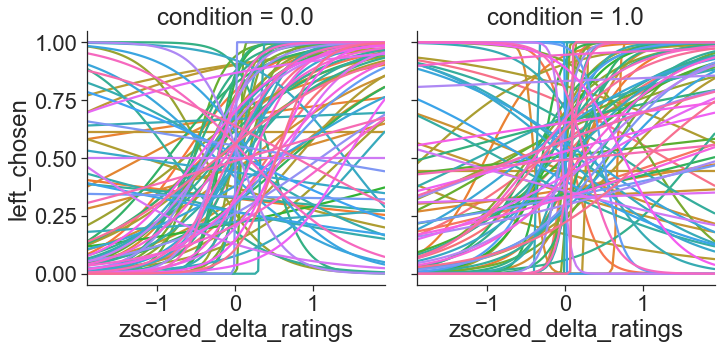

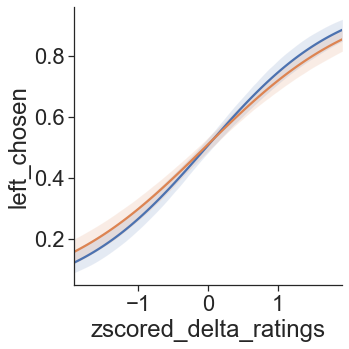

In [10]:
# logistic plots
sns.lmplot(data=dfs["deliberation"], x="zscored_delta_ratings", y="left_chosen", col="condition", hue="PID", ci=None,
               logistic=True, truncate=False, legend=None, scatter=False);
sns.lmplot(data=dfs["deliberation"], x="zscored_delta_ratings", y="left_chosen", hue="condition",
               logistic=True, truncate=False, legend=None, scatter=False);

### Probability to choose the novel item in Interference phase 

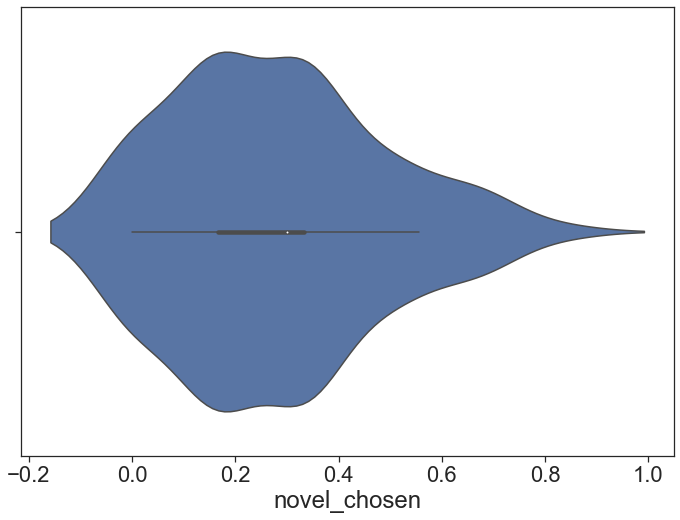

In [11]:
dfs["interference"]["novel_chosen"] = (dfs["interference"]["novel_left"] == dfs["interference"]["left_chosen"]).astype(int)
novel_inter = dfs["interference"].groupby("PID").agg(novel_chosen = ('novel_chosen', 'mean')).reset_index()
sns.violinplot(x=novel_inter["novel_chosen"]);

### choosing by ratings 

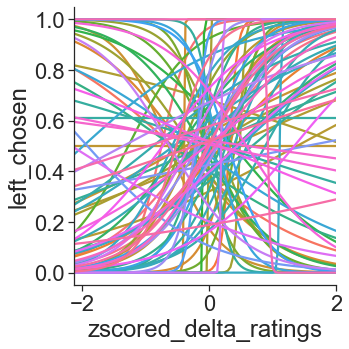

In [12]:
sns.lmplot(data=dfs["interference"], x="zscored_delta_ratings", y="left_chosen", hue="PID", ci=None,
               logistic=True, truncate=False, legend=None, scatter=False);

## Analysis of decision bias

In [13]:
p_gain = dfs["final_decisions"].groupby(["PID","chosen_trial","condition"]).agg(
    p_gain = ('higher_outcome_chosen','mean'),
    zscored_rt = ('zscored_rt', 'mean')).reset_index()
p_gain["chosen_trial"] = p_gain["chosen_trial"].replace({0: "Unchosen Pairs", 1: "Chosen Pairs"})
p_gain["condition"] = p_gain["condition"].replace({0: "Regular", 1: "Interference"})

/Users/nataliekataev/opt/anaconda3/envs/categories/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning: 26.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/nataliekataev/opt/anaconda3/envs/categories/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning: 29.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


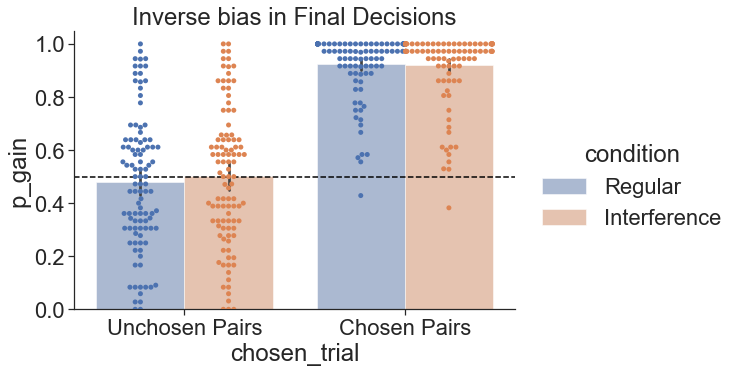

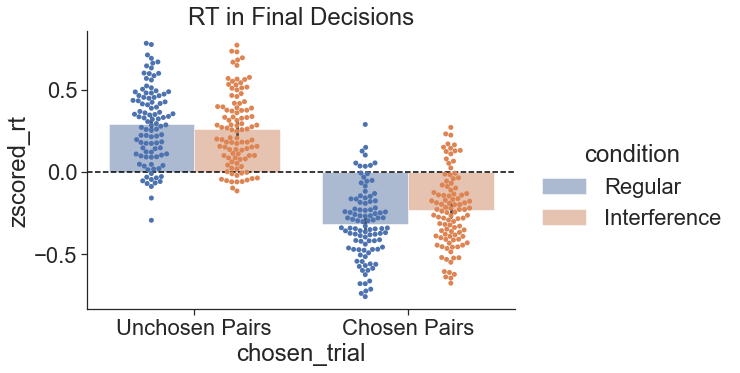

In [14]:
ax = sns.catplot(data = p_gain, 
                x="chosen_trial", y="p_gain", hue="condition", kind="bar", ci=95, aspect=1.5, alpha=0.5).map(
        plt.axhline, y=0.5, ls='--', c='black').set(
        ylabel="p(Choose Gain)",xlabel="Pair type", title="Inverse bias in Final Decisions")
ax = sns.swarmplot(data=p_gain, x="chosen_trial", y="p_gain", hue='condition', dodge=True)
ax.get_legend().set_visible(False)

ax = sns.catplot(data = p_gain, 
                x="chosen_trial", y="zscored_rt", hue='condition', kind="bar", ci=95, aspect=1.5, alpha=0.5).map(
        plt.axhline, y=0, ls='--', c='black').set(
        ylabel="z-scored RT",xlabel="Pair type", title="RT in Final Decisions")
ax = sns.swarmplot(data=p_gain, x="chosen_trial", y="zscored_rt", hue='condition', dodge=True)
ax.get_legend().set_visible(False)



RT for choosing the gain item (in our previous experiment we found faster responses to no gain in unchosen items)

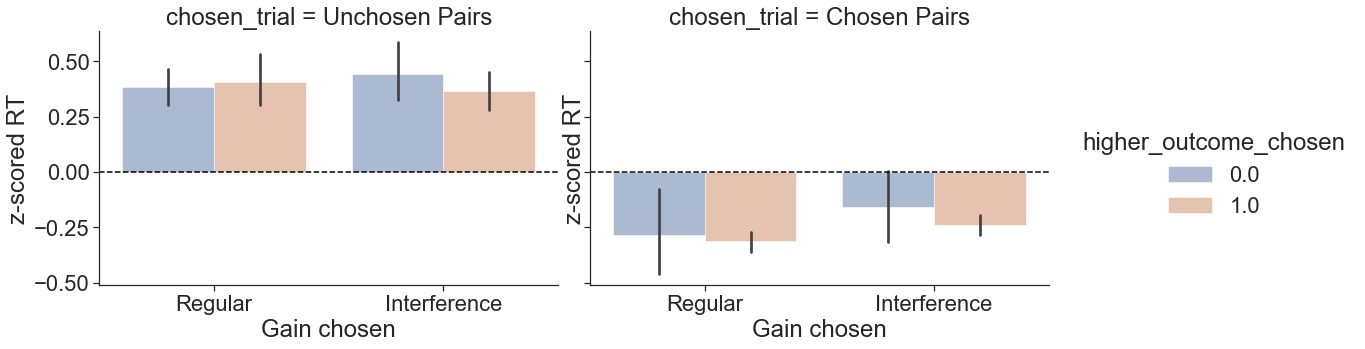

In [15]:
rt_gain_choice = dfs["final_decisions"].groupby(["PID","chosen_trial","condition","higher_outcome_chosen"]).agg(
    zscored_rt = ('zscored_rt', 'mean')).reset_index()
rt_gain_choice["chosen_trial"] = rt_gain_choice["chosen_trial"].replace({0: "Unchosen Pairs", 1: "Chosen Pairs"})
rt_gain_choice["condition"] = rt_gain_choice["condition"].replace({0: "Regular", 1: "Interference"})
ax = sns.catplot(data = rt_gain_choice, 
                col="chosen_trial", hue="higher_outcome_chosen", y="zscored_rt", x='condition', kind="bar", ci=95, aspect=1.5, alpha=0.5).map(
        plt.axhline, y=0, ls='--', c='black').set(
        ylabel="z-scored RT",xlabel="Gain chosen")
# ax = sns.swarmplot(data=rt_gain_choice, col="chosen_trial", x="higher_outcome_chosen", y="zscored_rt", hue='condition', dodge=True)
# ax.get_legend().set_visible(False)


### Decision bias and memory

In [16]:
pairs_acc = dfs["memory"].groupby(["PID", "condition"]).agg(pairs_acc = ('pairs_acc', 'mean')).reset_index()
pairs_acc["condition"] = pairs_acc["condition"].replace({0: "Regular", 1: "Interference"})
p_gain_memory = p_gain.merge(pairs_acc, on=["PID","condition"], how="inner")

Assess inverse bias and rt (chosen minus unchosen pairs) as a function of memory

In [17]:
p_gain_spread = p_gain_memory.drop(columns=["zscored_rt","pairs_acc"]).pivot_table(index=["PID","condition"],columns="chosen_trial",values="p_gain").reset_index()
p_gain_spread["inverse bias"] = p_gain_spread["Chosen Pairs"] - p_gain_spread["Unchosen Pairs"]
rt_spread = p_gain_memory.drop(columns=["p_gain","pairs_acc"]).pivot_table(index=["PID","condition"],columns="chosen_trial",values="zscored_rt").reset_index()
rt_spread["inverse zscored rt"] = rt_spread["Chosen Pairs"] - rt_spread["Unchosen Pairs"]
inverse_performance = p_gain_spread.drop(columns=["Chosen Pairs","Unchosen Pairs"]).merge(
    rt_spread.drop(columns=["Chosen Pairs","Unchosen Pairs"]), on=["PID","condition"]).merge(
    pairs_acc, on=["PID","condition"])


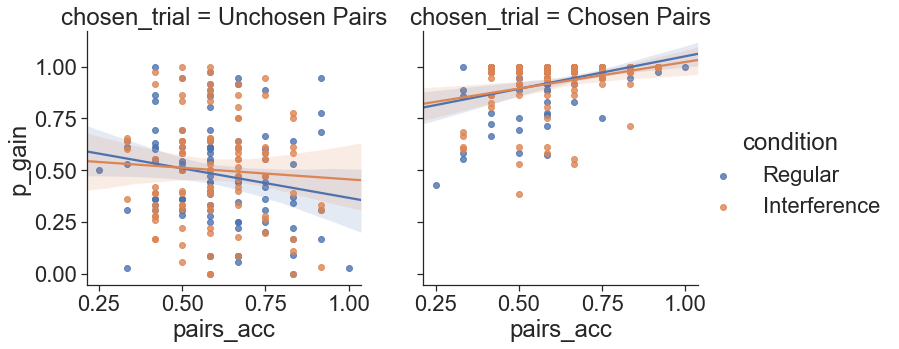

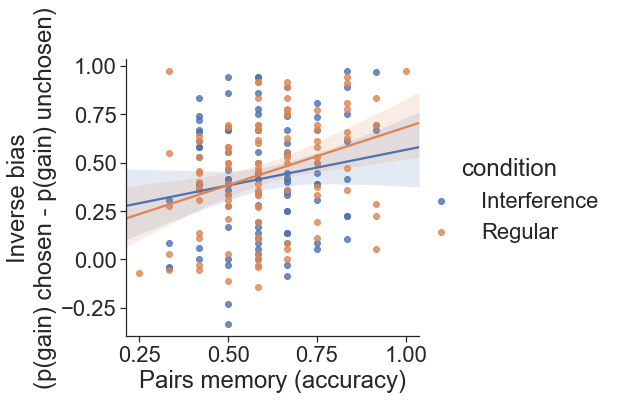

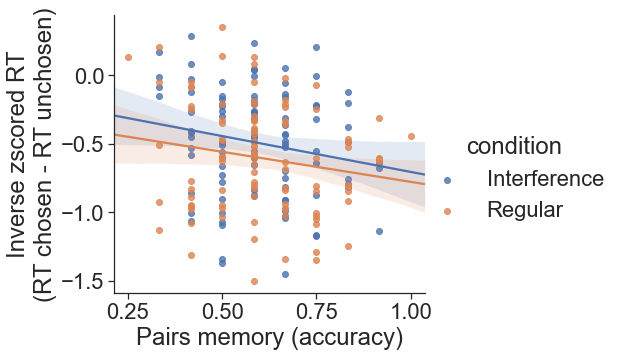

In [18]:
sns.lmplot(data=p_gain_memory, x="pairs_acc", y="p_gain", col="chosen_trial", hue="condition", ci=95, truncate=False);

sns.lmplot(data=inverse_performance, x="pairs_acc", y="inverse bias", hue="condition", ci=95, truncate=False, aspect=1.2).set(xlabel="Pairs memory (accuracy)", ylabel="Inverse bias\n(p(gain) chosen - p(gain) unchosen)");

sns.lmplot(data=inverse_performance, x="pairs_acc", y="inverse zscored rt", hue="condition", ci=95, truncate=False, aspect=1.2).set(xlabel="Pairs memory (accuracy)", ylabel="Inverse zscored RT\n(RT chosen - RT unchosen)");



Now assess individual differences in memory and p(gain) between the different conditions 

In [19]:
cond_spread_p_gain = p_gain_memory.drop(columns=["zscored_rt","pairs_acc"]).pivot_table(index=["PID","chosen_trial"],columns="condition",values="p_gain").reset_index()
cond_spread_p_gain["condition diff - choices"] = cond_spread_p_gain["Regular"] - cond_spread_p_gain["Interference"]
cond_spread_rt = p_gain_memory.drop(columns=["p_gain","pairs_acc"]).pivot_table(index=["PID","chosen_trial"],columns="condition",values="zscored_rt").reset_index()
cond_spread_rt["condition diff - zscored rt"] = cond_spread_rt["Regular"] - cond_spread_rt["Interference"]
cond_spread_pairs_acc = pairs_acc.pivot_table(index=["PID"],columns="condition",values="pairs_acc").reset_index()
cond_spread_pairs_acc["condition diff - pairs_acc"] = cond_spread_pairs_acc["Regular"] - cond_spread_pairs_acc["Interference"]

cond_diff_performance = cond_spread_p_gain.drop(columns=["Regular","Interference"]).merge(
    cond_spread_rt.drop(columns=["Regular","Interference"]), on=["PID","chosen_trial"]).merge(
    cond_spread_pairs_acc.drop(columns=["Regular","Interference"]), on=["PID"])

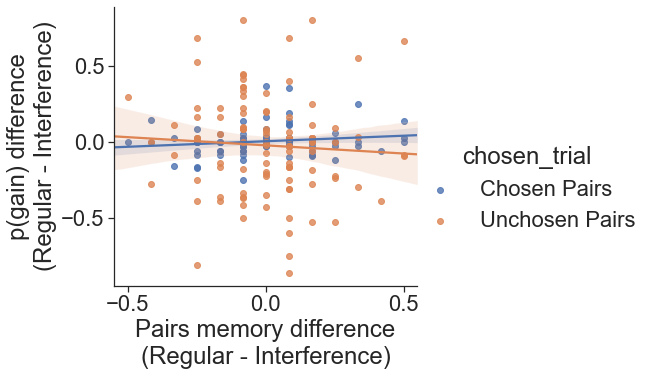

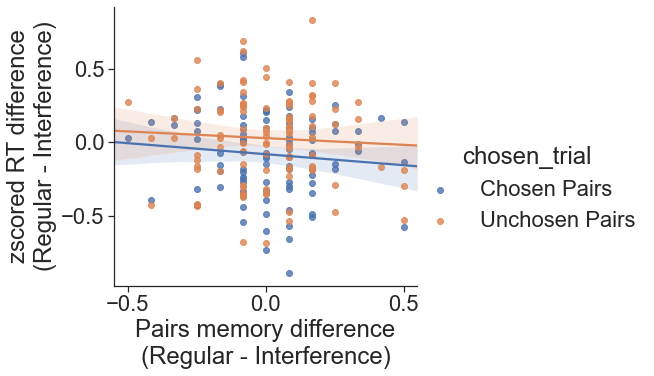

In [23]:
sns.lmplot(data=cond_diff_performance, x="condition diff - pairs_acc", y="condition diff - choices", hue="chosen_trial", ci=95, truncate=False, aspect=1.2).set(xlabel="Pairs memory difference\n(Regular - Interference)", ylabel="p(gain) difference\n(Regular - Interference)");
sns.lmplot(data=cond_diff_performance, x="condition diff - pairs_acc", y="condition diff - zscored rt", hue="chosen_trial", ci=95, truncate=False, aspect=1.2).set(xlabel="Pairs memory difference\n(Regular - Interference)", ylabel="zscored RT difference\n(Regular - Interference)");


/Users/nataliekataev/opt/anaconda3/envs/categories/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning: 5.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


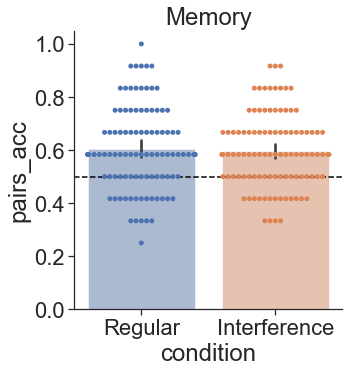

In [21]:
ax = sns.catplot(data = pairs_acc, 
                x="condition", y="pairs_acc", kind="bar", ci=95, alpha=0.5).map(
        plt.axhline, y=0.5, ls='--', c='black').set(
        ylabel="Memory accuracy",xlabel="Condition", title="Memory")
ax = sns.swarmplot(data=pairs_acc, x="condition", y="pairs_acc")


# Debriefing 

In [22]:
dfs["debrief"].iloc[0:50]

,PID,age,art_experience,art_time_spent,clear_instructions,dominant_hand,fluency,gender,native_language,strategy_FD,strategy_deliberation,strategy_interference,strategy_unchosen
0,06o3b,31,Enthusiast,1.0,Instructions were clear.,Right,4,Female,Yes,I just relied on my memory and how I liked the...,I just went with my personal preference and ho...,Same strategy as the first auction. I went wit...,I tried to choose the ones I already know it m...
1,0Zwdb,29,Novice,0.0,No,Right,4,Female,Yes,No,"No, just picked the ones I liked best",No,I picked the one I prefered
2,0au00,24,Enthusiast,5.0,No,Left,4,Male,Yes,I just picked which paintings i remembered pay...,I picked the paintings i personally liked the ...,No,I chose the one that was most favorable to me ...
3,1W5Bp,34,Enthusiast,1.0,no,Right,4,Male,Yes,I tried to compare the paintings to the ones I...,I tried to examine the quality and content for...,I tried not to make mistakes and choose simila...,Guessing and hoping any similarities they had ...
4,35vSZ,34,Novice,3.0,none,Right,4,Male,Yes,"No, I went with that I felt would be more appr...",I tried to decide based on the setting and col...,I went with what I remembered from the first a...,I chose based on which painting looked more so...
5,4llS3,31,Novice,1.0,No.,Right,4,Male,Yes,I selected paintings that I remembered to have...,I relied on instinct.,I tried to learn from the first auction and in...,I never chose a painting that had been shown t...
6,4xy5j,34,Novice,1.0,no,Right,4,Female,Yes,I chose the ones that I remember having a high...,I just picked the ones I liked and thought oth...,not that I can remember,I chose the ones that were most similar to the...
7,59tg8,33,Novice,1.0,no,Right,4,Male,Yes,"No, the memory part was very hard however.",I just went with the ones I liked most.,I just went with the ones I liked most.,I just went with paintings I like or ones that...
8,5AfPg,32,Enthusiast,6.0,NaN,Right,4,Male,Yes,"I didnt, I just chose what i enjoyed more.",I used my gut instinct,I used my gut instincts to choose what would b...,I still chose the one i enjoyed the most and t...
9,6IPcq,27,Novice,0.0,NaN,Right,4,Female,Yes,NaN,NaN,NaN,NaN
